In [2]:
import os
import sys
import pickle
from glob import glob
from warnings import filterwarnings
from colorsys import hsv_to_rgb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from data_readers.infrared import InfraredData
from data_readers.visualize import MatPlot3D

np.set_printoptions(precision=12, suppress=True)
filterwarnings("ignore", category=DeprecationWarning)

DATASET_PATH = os.path.abspath("../../../RF-Behavior")
DATASET_PATH, os.path.exists(DATASET_PATH)

('c:\\RF-Behavior', True)

## Infrared

In [5]:
path = "../../../RF-Behavior/InfraredCam/InfraredCam/C1/U01/M19/01.csv" # "two-hand-lateral-to-front"
ird = InfraredData.read_from_path(path)
display(InfraredData.read_csv(path).head(3))
ird.landmarks.shape, ird.landmarks[0], ird.timestamps.shape, ird.timestamps[:10]

,Name__Time (Seconds),Chest_Position_X,Chest_Position_Y,Chest_Position_Z,Chest_Rotation_X,Chest_Rotation_Y,Chest_Rotation_Z,Chest_Rotation_W,LeftArm_Position_X,LeftArm_Position_Y,...,LeftArm_Rotation_Y,LeftArm_Rotation_Z,LeftArm_Rotation_W,RightArm_Position_X,RightArm_Position_Y,RightArm_Position_Z,RightArm_Rotation_X,RightArm_Rotation_Y,RightArm_Rotation_Z,RightArm_Rotation_W
0,0.00,37.729137,1254.272095,-231.115051,0.540477,0.013823,-0.004214,0.841235,-309.376038,1375.522095,...,-0.743586,0.184644,0.595923,394.502777,1383.095947,-399.958771,0.164626,-0.694042,0.196807,-0.672660
1,0.01,37.742527,1254.208740,-231.032928,0.541384,0.013931,-0.004521,0.840648,-309.318695,1375.656860,...,-0.743478,0.184151,0.595774,394.574310,1383.071899,-399.780334,0.164444,-0.694253,0.196295,-0.672636
2,0.02,37.793034,1254.167969,-230.945908,0.542849,0.014016,-0.005269,0.839697,-309.242645,1375.827881,...,-0.743431,0.184033,0.595890,394.626251,1383.108398,-399.654449,0.163673,-0.694171,0.196373,-0.672886


((269, 3, 7),
 array([[  37.729137, 1254.2721  , -231.11505 ,    0.540477,    0.013823,
           -0.004214,    0.841235],
        [ 394.50278 , 1383.096   , -399.95877 ,    0.164626,   -0.694042,
            0.196807,   -0.67266 ],
        [-309.37604 , 1375.5221  , -478.56342 ,   -0.240547,   -0.743586,
            0.184644,    0.595923]], dtype=float32),
 (269,),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09],
       dtype=float32))

In [15]:
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C1/U03/M15/01.csv" # "left-arm-circle"
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C1/U01/M16/01.csv" # "right-arm-circle"
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C1/U32/M07/01.csv" # "swipe-right"
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C1/U01/M08/01.csv" # "swipe-left"
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C2/U03/A01/01.csv"  # walking # +y = above
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C2/U03/A04/01.csv"  # sitting # +y = above
path = "../../../RF-Behavior/InfraredCam/InfraredCam/C2/U32/A10/02.csv"  # kick-football # +y = above
# path = "../../../RF-Behavior/InfraredCam/InfraredCam/C3/U03/E01/01.csv"  # focus
# ird = InfraredData.read_from_path(path, transform=True, normalize=True)
ird = InfraredData.read_from_path(path)

step = 12
points = ird.landmarks[:2000:step, :, :3]
print(points.shape )

connections = [(0,1), (0,2), (0,3), (3,4), (3,5)][:points.shape[1]-1]
line_labels =   [               'LeftArm',     'RightArm', 'torso',          'LeftLeg', 'RightLeg'][:points.shape[1]-1]
line_colors =   [               "magenta",     "cyan",     "black",          "red",     "blue"    ][:points.shape[1]-1]
scatter_color = ["lawngreen",   "darkmagenta", "darkcyan", "darkolivegreen", "darkred", "darkblue"][:points.shape[1]  ]
anim = MatPlot3D.animate(points, vertical_axis="y", azimuth=40, elevation=10,
    line_indexes=connections, line_labels=line_labels, line_colors=line_colors,
    scatter_colors=[scatter_color] * len(points), scatter_size=10,
    )
plt.close()
display(HTML(anim.to_jshtml(fps=round(100/step))))

(23, 6, 3)


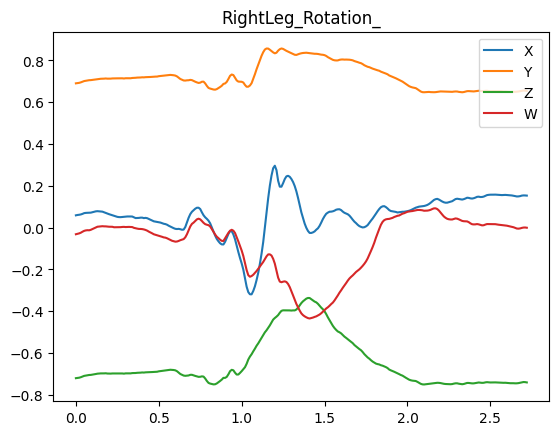

In [19]:
bp_idx = 5
for i in range(3,7):
    plt.plot(ird.timestamps, ird.landmarks[:, bp_idx, i], label="XYZW"[i-3])
plt.title(InfraredData.BODY_PARTS[bp_idx] + "_Rotation_")
plt.legend()

In [ ]:
# from tqdm.auto import tqdm
# from concurrent.futures import ThreadPoolExecutor
# import warnings

# files = glob("../../../RF-Behavior/InfraredCam/**/*.csv", recursive=True)
# np.random.shuffle(files)

# def process_path(p):
#     rd = InfraredData.read_from_path(p, transform=True, normalize=False)
#     if np.isnan(rd.landmarks).any():
#         warnings.warn(f"NaN values found in landmarks for file '{p}'")
#     concat = np.concatenate(rd.landmarks, axis=0)
#     return concat.mean(axis=0), concat.std(axis=0), len(concat), p

# with ThreadPoolExecutor(max_workers=16) as executor:
#     results = list(tqdm(executor.map(process_path, files), total=len(files)))
#     means, stds, ns, paths = zip(*results)

In [ ]:
# np.average(means, axis=0, weights=ns),\
# np.average(stds, axis=0, weights=ns)

(array([   3.248380930763,  922.046612473506, -240.151300320984,
          -0.001156634352,    0.00849719666 ,    0.000139222646,
          -0.00817210628 ]),
 array([473.229016340735, 193.943481061356, 218.677452467549,
          0.484396761754,   0.267481151044,   0.249025394452,
          0.588057615433]))